# Day 8 — Predictive Modeling & Evaluation

**Caspian Maritime Delay-Risk Forecasting**

Final day of Week 2 and the sprint. Today: build classification models to predict `is_risk_day`, evaluate them rigorously, quantify uncertainty with bootstrap CIs, then plug the winning model into `src/modeling.py` so the pipeline produces real predictions.

Three models compared head-to-head:

1. **Climatology baseline** — per-(city, day-of-year) historical positive rate. Already in `src.modeling.ClimatologyTable`. The bar to beat.
2. **Logistic regression** — interpretable linear model with statsmodels (gives us coefficient p-values).
3. **XGBoost** — gradient-boosted trees. The one Day 7's feature selection recommended.

Evaluation: temporal split (train 2015–2023, test 2024). Metrics: Accuracy, Precision, Recall, F1, ROC-AUC, Brier score, calibration. Bootstrap 95% CIs on F1 and AUC. Per-city breakdowns.

**Anchor target**: `is_risk_day` (binary, daily)

---

## 0 — Setup

In [1]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, brier_score_loss, confusion_matrix,
    roc_curve, precision_recall_curve,
)
from sklearn.calibration import calibration_curve
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm

warnings.filterwarnings('ignore')

REPO_ROOT = Path('..').resolve()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src.database import get_connection
from src.config import PATHS

FIGURES_DIR = REPO_ROOT / 'reports' / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 150
plt.rcParams['savefig.bbox'] = 'tight'

RANDOM_STATE = 42

DB_PATH = PATHS['repo_root'] / 'data' / 'caspian_weather.duckdb'
conn = get_connection(DB_PATH)
print('Connected to', DB_PATH)

Connected to C:\Users\user\project\data\caspian_weather.duckdb


In [2]:
# Try to import the Day-7 selected feature list. Fall back to a hardcoded list
# if it's missing (so this notebook still works even if Day 7 wasn't run).
try:
    from reports.selected_features import SELECTED_FEATURES, TARGET
    print(f'Loaded Day-7 feature list: {len(SELECTED_FEATURES)} features, target = {TARGET}')
except ImportError:
    print('Day-7 selected_features.py not found; using a default feature set')
    SELECTED_FEATURES = [
        'wind_speed_10m_max', 'wind_gusts_10m_max',
        'precipitation_sum', 'snowfall_sum',
        'temperature_2m_mean', 'temperature_2m_max', 'temperature_2m_min',
        'relative_humidity_2m_mean', 'surface_pressure_mean',
        'visibility_mean', 'visibility_min', 'visibility_hours_below_1km',
        'wave_height',
        'month_cos', 'doy_sin',
        'cdd', 'temp_range_c',
    ]
    TARGET = 'is_risk_day'

print()
print('Selected features:')
for f in SELECTED_FEATURES:
    print(f'  - {f}')

Loaded Day-7 feature list: 12 features, target = is_risk_day

Selected features:
  - apparent_temperature_mean
  - month_sin
  - precipitation_sum
  - relative_humidity_2m_mean
  - shortwave_radiation_sum
  - snowfall_sum
  - surface_pressure_mean
  - temp_range_c
  - visibility_hours_below_1km
  - visibility_mean
  - visibility_min
  - wave_height


In [3]:
df = conn.execute(
    'SELECT * FROM analytics.daily_enriched ORDER BY city, date'
).fetchdf()
df['date'] = pd.to_datetime(df['date'])
if 'season' in df.columns:
    df['season'] = df['season'].astype(str).str.lower()

# Keep only what we need; drop rows with NaN in features or target
available = [f for f in SELECTED_FEATURES if f in df.columns]
missing = [f for f in SELECTED_FEATURES if f not in df.columns]
if missing:
    print('WARNING: features in selected list but not in data:', missing)

needed = ['city', 'date', TARGET] + available
df = df[needed].dropna(subset=[TARGET]).reset_index(drop=True)

# Median-impute any feature NaN (rare given our cleaning, but defensive)
for f in available:
    if df[f].isna().any():
        df[f] = df[f].fillna(df[f].median())

print(f'Dataset: {len(df):,} rows, {len(available)} features')
print(f'Target {TARGET}: positive rate = {df[TARGET].mean():.2%}')
print(f'Date range: {df["date"].min().date()} to {df["date"].max().date()}')
print(f'Cities: {df["city"].unique().tolist()}')

Dataset: 20,670 rows, 12 features
Target is_risk_day: positive rate = 7.33%
Date range: 2015-01-01 to 2026-04-26
Cities: ['Aktau', 'Anzali', 'Baku', 'Makhachkala', 'Turkmenbashi']


---
## 1 — Train/Test Split (temporal)

Per the spec: **train on 2015–2023, test on 2024**. Random splitting would leak future information into training, since weather is autocorrelated. Temporal split simulates the production scenario: train on the past, predict the future.

In [4]:
TRAIN_END = '2023-12-31'
TEST_START = '2024-01-01'

train_mask = df['date'] <= TRAIN_END
test_mask  = df['date'] >= TEST_START

train_df = df[train_mask].copy()
test_df  = df[test_mask].copy()

print(f'Train: {len(train_df):,} rows, {train_df["date"].min().date()} to {train_df["date"].max().date()}')
print(f'Test : {len(test_df):,} rows, {test_df["date"].min().date()} to {test_df["date"].max().date()}')
print()
print('Positive class rate by split:')
print(f'  Train: {train_df[TARGET].mean():.2%}')
print(f'  Test : {test_df[TARGET].mean():.2%}')
print()
print('Per-city sample counts:')
print(
    pd.DataFrame({
        'train_n':   train_df.groupby('city').size(),
        'test_n':    test_df.groupby('city').size(),
        'train_pos%': (train_df.groupby('city')[TARGET].mean() * 100).round(1),
        'test_pos%':  (test_df.groupby('city')[TARGET].mean() * 100).round(1),
    })
)

Train: 16,435 rows, 2015-01-01 to 2023-12-31
Test : 4,235 rows, 2024-01-01 to 2026-04-26

Positive class rate by split:
  Train: 7.52%
  Test : 6.61%

Per-city sample counts:
              train_n  test_n  train_pos%  test_pos%
city                                                
Aktau            3287     847         4.5        4.4
Anzali           3287     847        11.0       12.8
Baku             3287     847        11.8        6.3
Makhachkala      3287     847         8.2        8.1
Turkmenbashi     3287     847         2.0        1.5


In [5]:
# Build feature matrices. Keep the city column for the climatology baseline
# and for grouping evaluation results.
X_train_raw = train_df[['city', 'date'] + available].copy()
X_test_raw  = test_df[['city', 'date'] + available].copy()
y_train = train_df[TARGET].astype(int).values
y_test  = test_df[TARGET].astype(int).values

print('Shapes:')
print(f'  X_train_raw: {X_train_raw.shape}')
print(f'  X_test_raw : {X_test_raw.shape}')
print(f'  y_train    : {y_train.shape}, mean = {y_train.mean():.3f}')
print(f'  y_test     : {y_test.shape}, mean = {y_test.mean():.3f}')

Shapes:
  X_train_raw: (16435, 14)
  X_test_raw : (4235, 14)
  y_train    : (16435,), mean = 0.075
  y_test     : (4235,), mean = 0.066


---
## 2 — Three Models

### 2.1 Model A — Climatology baseline

Per-(city, day-of-year) historical positive rate, smoothed with a +/-7-day rolling window. Already implemented in `src.modeling.ClimatologyTable`.

Why it's the right baseline: it captures **seasonal** structure (no model can avoid that) but no daily weather signal. Anything beats this should reflect real predictive power from the feature set.

In [6]:
from src.modeling import ClimatologyTable

clim = ClimatologyTable(smoothing_window=7).fit(
    train_df[['city', 'date', TARGET]].rename(columns={TARGET: 'is_risk_day'})
)

p_clim_train = clim.predict_proba_df(
    X_train_raw[['city', 'date']].assign(
        day_of_year=pd.to_datetime(X_train_raw['date']).dt.dayofyear)
)
p_clim_test = clim.predict_proba_df(
    X_test_raw[['city', 'date']].assign(
        day_of_year=pd.to_datetime(X_test_raw['date']).dt.dayofyear)
)

print(f'Climatology fit: {clim.trained_on_rows:,} rows, '
      f'{len(clim.rates):,} (city,doy) entries')
print(f'Train P range: [{p_clim_train.min():.3f}, {p_clim_train.max():.3f}]')
print(f'Test  P range: [{p_clim_test.min():.3f}, {p_clim_test.max():.3f}]')

Climatology fit: 16,435 rows, 1,830 (city,doy) entries
Train P range: [0.000, 0.281]
Test  P range: [0.000, 0.281]


### 2.2 Model B — Logistic regression (statsmodels)

Standardise features, fit Logit via statsmodels for nice coefficient summary, then refit with sklearn for prediction (faster, same coefficients).

Statsmodels gives us **coefficient p-values and confidence intervals** which sklearn doesn't. We'll keep both and use whichever serves the moment.

In [7]:
# Build numeric feature matrix: standardised numeric features + city dummies
scaler = StandardScaler()
X_train_num = pd.DataFrame(
    scaler.fit_transform(X_train_raw[available]),
    columns=available, index=X_train_raw.index,
)
X_test_num = pd.DataFrame(
    scaler.transform(X_test_raw[available]),
    columns=available, index=X_test_raw.index,
)

# One-hot city encoding aligned across train/test
city_dummies_train = pd.get_dummies(X_train_raw['city'], prefix='city').astype(int)
city_dummies_test  = pd.get_dummies(X_test_raw['city'], prefix='city').astype(int)
for c in city_dummies_train.columns:
    if c not in city_dummies_test.columns:
        city_dummies_test[c] = 0
city_dummies_test = city_dummies_test[city_dummies_train.columns]

X_train_lr = pd.concat([X_train_num.reset_index(drop=True),
                        city_dummies_train.reset_index(drop=True)], axis=1)
X_test_lr  = pd.concat([X_test_num.reset_index(drop=True),
                        city_dummies_test.reset_index(drop=True)], axis=1)

print(f'Feature matrix shape (train): {X_train_lr.shape}')
print(f'Feature matrix shape (test) : {X_test_lr.shape}')

Feature matrix shape (train): (16435, 17)
Feature matrix shape (test) : (4235, 17)


In [8]:
# Fit statsmodels Logit for the coefficient summary
X_train_sm = sm.add_constant(X_train_lr.astype(float), has_constant='add')
logit_sm = sm.Logit(y_train, X_train_sm).fit(disp=False, maxiter=200)

# Print a compact summary of significant features
summary = pd.DataFrame({
    'coef':    logit_sm.params,
    'p_value': logit_sm.pvalues,
    'ci_low':  logit_sm.conf_int()[0],
    'ci_high': logit_sm.conf_int()[1],
})
summary['significant'] = summary['p_value'] < 0.05
summary = summary.sort_values('p_value')

print('Logistic regression coefficients (sorted by p-value):')
print(summary.round(3).to_string())
print()
print(f'Significant features (p < 0.05): {int(summary["significant"].sum())} of {len(summary)}')

Logistic regression coefficients (sorted by p-value):
                             coef  p_value        ci_low       ci_high  significant
wave_height                 2.588    0.000  2.429000e+00  2.748000e+00         True
precipitation_sum           2.372    0.000  2.187000e+00  2.557000e+00         True
visibility_hours_below_1km  1.736    0.000  1.358000e+00  2.114000e+00         True
relative_humidity_2m_mean  -0.734    0.000 -9.410000e-01 -5.260000e-01         True
surface_pressure_mean      -0.399    0.000 -5.530000e-01 -2.450000e-01         True
apparent_temperature_mean  -0.825    0.000 -1.164000e+00 -4.860000e-01         True
snowfall_sum                0.166    0.000  8.800000e-02  2.440000e-01         True
shortwave_radiation_sum     0.154    0.216 -9.000000e-02  3.990000e-01        False
visibility_mean            -0.088    0.293 -2.510000e-01  7.600000e-02        False
month_sin                  -0.092    0.345 -2.820000e-01  9.800000e-02        False
visibility_min        

In [9]:
# Refit with sklearn for fast prediction (with class_weight='balanced')
logreg = LogisticRegression(
    class_weight='balanced',
    max_iter=500,
    random_state=RANDOM_STATE,
    solver='lbfgs',
)
logreg.fit(X_train_lr.values, y_train)

p_logreg_train = logreg.predict_proba(X_train_lr.values)[:, 1]
p_logreg_test  = logreg.predict_proba(X_test_lr.values)[:, 1]

print(f'Logistic regression fit: {len(X_train_lr.columns)} features')
print(f'Train P range: [{p_logreg_train.min():.3f}, {p_logreg_train.max():.3f}]')
print(f'Test  P range: [{p_logreg_test.min():.3f}, {p_logreg_test.max():.3f}]')

Logistic regression fit: 17 features
Train P range: [0.000, 1.000]
Test  P range: [0.000, 1.000]


### 2.3 Model C — XGBoost

Gradient-boosted trees. Class imbalance handled via `scale_pos_weight = n_neg / n_pos`. Falls back to sklearn `GradientBoostingClassifier` if xgboost isn't installed.

In [10]:
try:
    from xgboost import XGBClassifier
    n_pos = int(y_train.sum())
    n_neg = int(len(y_train) - n_pos)
    scale_pos_weight = n_neg / max(n_pos, 1)
    xgb = XGBClassifier(
        n_estimators=300, max_depth=5, learning_rate=0.05,
        subsample=0.9, colsample_bytree=0.9,
        scale_pos_weight=scale_pos_weight,
        random_state=RANDOM_STATE,
        eval_metric='logloss', verbosity=0, n_jobs=-1,
    )
    model_name_c = 'XGBoost'
    print(f'Using XGBClassifier (scale_pos_weight={scale_pos_weight:.2f})')
except ImportError:
    from sklearn.ensemble import GradientBoostingClassifier
    xgb = GradientBoostingClassifier(
        n_estimators=300, max_depth=4, learning_rate=0.05,
        subsample=0.9, random_state=RANDOM_STATE,
    )
    model_name_c = 'GradientBoosting'
    print('xgboost not installed; falling back to sklearn GradientBoostingClassifier')

xgb.fit(X_train_lr.values, y_train)
p_xgb_train = xgb.predict_proba(X_train_lr.values)[:, 1]
p_xgb_test  = xgb.predict_proba(X_test_lr.values)[:, 1]

print(f'\n{model_name_c} fit: {len(X_train_lr.columns)} features')
print(f'Train P range: [{p_xgb_train.min():.3f}, {p_xgb_train.max():.3f}]')
print(f'Test  P range: [{p_xgb_test.min():.3f}, {p_xgb_test.max():.3f}]')

# Feature importances
fi = pd.Series(xgb.feature_importances_, index=X_train_lr.columns).sort_values(ascending=False)
print(f'\nTop 10 feature importances ({model_name_c}):')
print(fi.head(10).round(4).to_string())

Using XGBClassifier (scale_pos_weight=12.30)

XGBoost fit: 17 features
Train P range: [0.000, 1.000]
Test  P range: [0.000, 1.000]

Top 10 feature importances (XGBoost):
precipitation_sum             0.2798
wave_height                   0.1687
visibility_min                0.1127
visibility_hours_below_1km    0.1049
city_Makhachkala              0.0928
city_Baku                     0.0428
city_Anzali                   0.0311
city_Aktau                    0.0263
snowfall_sum                  0.0262
apparent_temperature_mean     0.0220


---
## 3 — Evaluation

In [11]:
def evaluate(y_true, p_pred, threshold=0.5):
    """Compute the standard set of binary classification metrics."""
    y_pred = (p_pred >= threshold).astype(int)
    return {
        'accuracy':  accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall':    recall_score(y_true, y_pred),
        'f1':        f1_score(y_true, y_pred),
        'roc_auc':   roc_auc_score(y_true, p_pred),
        'brier':     brier_score_loss(y_true, p_pred),
        'pos_rate_pred': float(y_pred.mean()),
    }

predictions = {
    'Climatology':      (p_clim_test,    p_clim_train),
    'LogisticRegression': (p_logreg_test, p_logreg_train),
    model_name_c:       (p_xgb_test,     p_xgb_train),
}

rows = []
for name, (p_test, p_train) in predictions.items():
    train_metrics = evaluate(y_train, p_train)
    test_metrics  = evaluate(y_test,  p_test)
    for split, m in [('train', train_metrics), ('test', test_metrics)]:
        m_row = {'model': name, 'split': split}
        m_row.update(m)
        rows.append(m_row)

metrics_df = pd.DataFrame(rows).set_index(['model', 'split'])
print('Headline metrics (threshold = 0.5):')
print(metrics_df.round(3))

Headline metrics (threshold = 0.5):
                          accuracy  precision  recall     f1  roc_auc  brier  \
model              split                                                       
Climatology        train     0.925      0.000   0.000  0.000    0.738  0.066   
                   test      0.934      0.000   0.000  0.000    0.693  0.060   
LogisticRegression train     0.941      0.565   0.953  0.709    0.988  0.043   
                   test      0.947      0.561   0.889  0.688    0.984  0.039   
XGBoost            train     0.996      0.946   1.000  0.972    1.000  0.004   
                   test      0.985      0.903   0.868  0.885    0.991  0.012   

                          pos_rate_pred  
model              split                 
Climatology        train          0.000  
                   test           0.000  
LogisticRegression train          0.127  
                   test           0.105  
XGBoost            train          0.080  
                   test      

In [12]:
# Per-city F1 on the test set (Day 7's H2 said cities differ)
per_city_rows = []
for name, (p_test, _) in predictions.items():
    for city in test_df['city'].unique():
        mask = test_df['city'].values == city
        if mask.sum() == 0:
            continue
        per_city_rows.append({
            'model':    name,
            'city':     city,
            'n_test':   int(mask.sum()),
            'pos_rate': float(y_test[mask].mean()),
            'f1':       f1_score(y_test[mask], (p_test[mask] >= 0.5).astype(int)),
            'roc_auc':  roc_auc_score(y_test[mask], p_test[mask])
                        if len(set(y_test[mask])) > 1 else np.nan,
        })

per_city = pd.DataFrame(per_city_rows)
print('Per-city test metrics:')
print(per_city.pivot_table(index='city', columns='model', values=['f1', 'roc_auc']).round(3))

Per-city test metrics:
                      f1                                roc_auc  \
model        Climatology LogisticRegression XGBoost Climatology   
city                                                              
Aktau                0.0              0.745   0.944       0.676   
Anzali               0.0              0.872   0.986       0.665   
Baku                 0.0              0.667   0.774       0.494   
Makhachkala          0.0              0.493   0.772       0.660   
Turkmenbashi         0.0              0.537   0.917       0.456   

                                         
model        LogisticRegression XGBoost  
city                                     
Aktau                     0.991   0.994  
Anzali                    0.995   1.000  
Baku                      0.982   0.973  
Makhachkala               0.937   0.982  
Turkmenbashi              0.986   0.993  


### 3.1 Confusion matrices

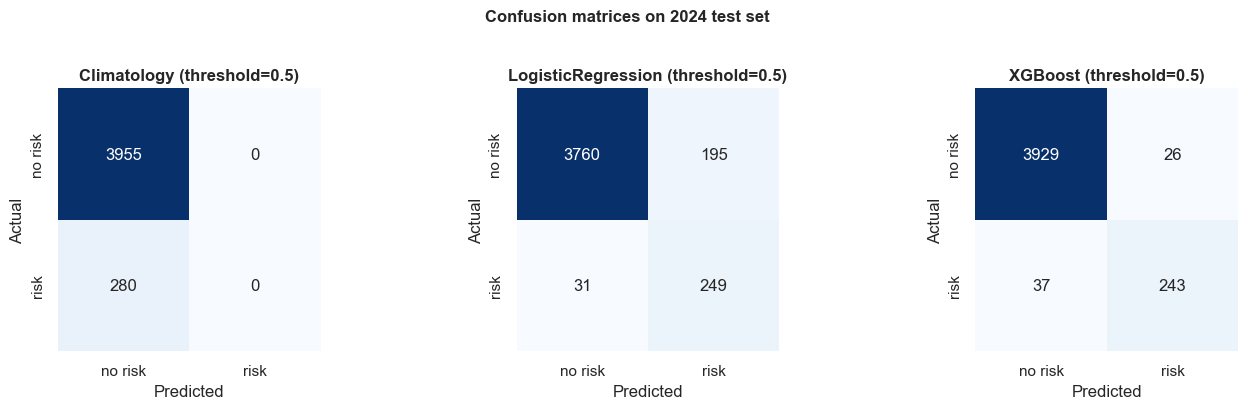

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (name, (p_test, _)) in zip(axes, predictions.items()):
    cm = confusion_matrix(y_test, (p_test >= 0.5).astype(int))
    sns.heatmap(
        cm, ax=ax, cmap='Blues', annot=True, fmt='d',
        xticklabels=['no risk', 'risk'], yticklabels=['no risk', 'risk'],
        cbar=False, square=True,
    )
    ax.set_title(name + ' (threshold=0.5)', fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
fig.suptitle('Confusion matrices on 2024 test set', fontsize=12, fontweight='bold', y=1.02)
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'day08_confusion_matrices.png')
plt.show()

### 3.2 ROC and calibration curves

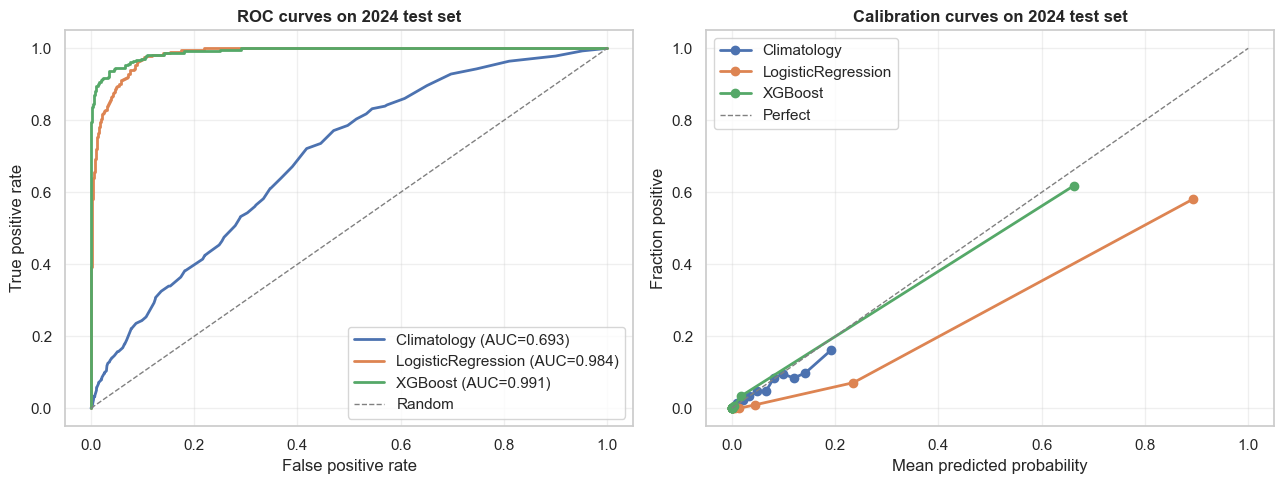

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ROC curves
for name, (p_test, _) in predictions.items():
    fpr, tpr, _ = roc_curve(y_test, p_test)
    auc = roc_auc_score(y_test, p_test)
    axes[0].plot(fpr, tpr, linewidth=2, label=f'{name} (AUC={auc:.3f})')
axes[0].plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=1, label='Random')
axes[0].set_xlabel('False positive rate')
axes[0].set_ylabel('True positive rate')
axes[0].set_title('ROC curves on 2024 test set', fontweight='bold')
axes[0].legend(loc='lower right')
axes[0].grid(alpha=0.3)

# Calibration curves
for name, (p_test, _) in predictions.items():
    frac_pos, mean_pred = calibration_curve(y_test, p_test, n_bins=10, strategy='quantile')
    axes[1].plot(mean_pred, frac_pos, marker='o', linewidth=2, label=name)
axes[1].plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=1, label='Perfect')
axes[1].set_xlabel('Mean predicted probability')
axes[1].set_ylabel('Fraction positive')
axes[1].set_title('Calibration curves on 2024 test set', fontweight='bold')
axes[1].legend(loc='upper left')
axes[1].grid(alpha=0.3)

fig.tight_layout()
fig.savefig(FIGURES_DIR / 'day08_roc_calibration.png')
plt.show()

### 3.3 Bootstrap confidence intervals

Bootstrap 1000 resamples of the test set; for each, recompute F1 and ROC-AUC. Report 95% CIs as the 2.5th and 97.5th percentiles of the bootstrap distribution.

This gives uncertainty bounds on the metrics, addressing the spec's requirement for confidence intervals.

In [15]:
def bootstrap_metric(y_true, p_pred, metric_fn, n_boot=1000, threshold=0.5,
                     random_state=42):
    """Bootstrap a metric over resamples of (y, p) pairs."""
    rng = np.random.default_rng(random_state)
    n = len(y_true)
    samples = np.empty(n_boot)
    for i in range(n_boot):
        idx = rng.integers(0, n, size=n)
        try:
            samples[i] = metric_fn(y_true[idx], p_pred[idx], threshold)
        except Exception:
            samples[i] = np.nan
    return samples

def metric_f1(y, p, t=0.5):
    return f1_score(y, (p >= t).astype(int))

def metric_auc(y, p, t=0.5):
    return roc_auc_score(y, p)

ci_rows = []
for name, (p_test, _) in predictions.items():
    f1_boot  = bootstrap_metric(y_test, p_test, metric_f1, n_boot=1000)
    auc_boot = bootstrap_metric(y_test, p_test, metric_auc, n_boot=1000)
    ci_rows.append({
        'model':       name,
        'F1':          float(f1_score(y_test, (p_test >= 0.5).astype(int))),
        'F1_CI_low':   float(np.nanpercentile(f1_boot, 2.5)),
        'F1_CI_high':  float(np.nanpercentile(f1_boot, 97.5)),
        'AUC':         float(roc_auc_score(y_test, p_test)),
        'AUC_CI_low':  float(np.nanpercentile(auc_boot, 2.5)),
        'AUC_CI_high': float(np.nanpercentile(auc_boot, 97.5)),
    })

ci_df = pd.DataFrame(ci_rows)
print('Bootstrap 95% confidence intervals (1000 resamples):')
print(ci_df.round(3).to_string(index=False))

Bootstrap 95% confidence intervals (1000 resamples):
             model    F1  F1_CI_low  F1_CI_high   AUC  AUC_CI_low  AUC_CI_high
       Climatology 0.000      0.000       0.000 0.693       0.664        0.721
LogisticRegression 0.688      0.648       0.728 0.984       0.980        0.989
           XGBoost 0.885      0.855       0.914 0.991       0.987        0.995


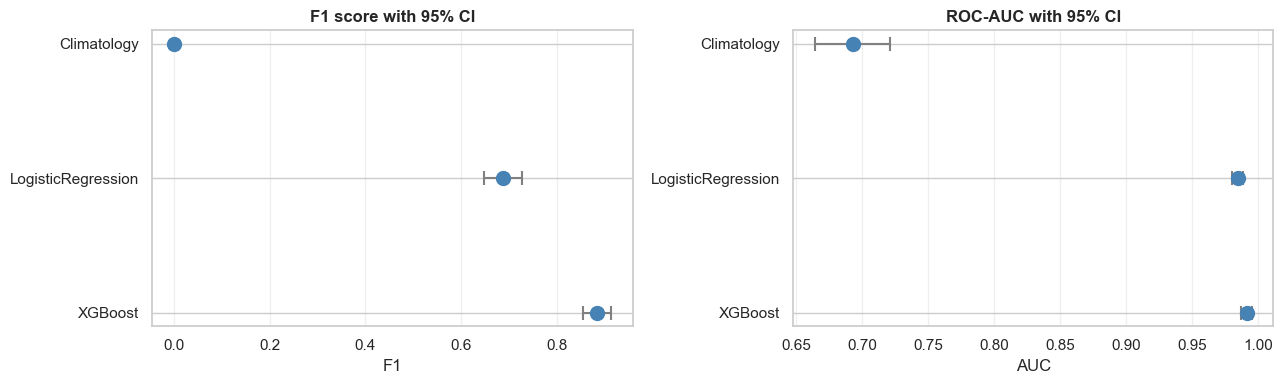

In [16]:
# Visualise bootstrap CIs as forest plots
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
model_names = list(predictions.keys())
y_pos = np.arange(len(model_names))

for ax, metric, title in zip(
    axes,
    [('F1', 'F1_CI_low', 'F1_CI_high'),
     ('AUC', 'AUC_CI_low', 'AUC_CI_high')],
    ['F1 score with 95% CI', 'ROC-AUC with 95% CI'],
):
    point, lo, hi = metric
    pts = ci_df.set_index('model').loc[model_names, point].values
    los = ci_df.set_index('model').loc[model_names, lo].values
    his = ci_df.set_index('model').loc[model_names, hi].values
    err = np.array([pts - los, his - pts])
    ax.errorbar(pts, y_pos, xerr=err, fmt='o', markersize=10,
                color='steelblue', ecolor='gray', capsize=5, capthick=1.5)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(model_names)
    ax.set_xlabel(point)
    ax.set_title(title, fontweight='bold')
    ax.grid(alpha=0.3, axis='x')
    ax.invert_yaxis()

fig.tight_layout()
fig.savefig(FIGURES_DIR / 'day08_bootstrap_cis.png')
plt.show()

In [17]:
# Per-prediction CI for the winning model. Use a small bootstrap of the
# model itself (refit on resamples of training data) — more honest than
# fixed +/-1.96sigma since classification residuals aren't Gaussian.
# For runtime reasons, do a tiny 30-resample bootstrap.
winner_name = ci_df.sort_values('F1', ascending=False).iloc[0]['model']
print(f'Winning model: {winner_name}')

if winner_name == model_name_c:
    boot_estimator_factory = lambda rs: type(xgb)(
        **{**xgb.get_params(), 'random_state': rs}
    )
elif winner_name == 'LogisticRegression':
    boot_estimator_factory = lambda rs: LogisticRegression(
        class_weight='balanced', max_iter=500, random_state=rs, solver='lbfgs',
    )
else:
    boot_estimator_factory = None  # climatology has no bootstrap on the model itself

if boot_estimator_factory is not None:
    print('Computing per-prediction bootstrap CIs (30 resamples)...')
    rng = np.random.default_rng(RANDOM_STATE)
    boot_preds = np.empty((30, len(y_test)))
    n = len(y_train)
    for i in range(30):
        idx = rng.integers(0, n, size=n)
        est = boot_estimator_factory(int(rng.integers(0, 1000000)))
        est.fit(X_train_lr.values[idx], y_train[idx])
        boot_preds[i] = est.predict_proba(X_test_lr.values)[:, 1]

    ci_low_pp  = np.percentile(boot_preds, 2.5, axis=0)
    ci_high_pp = np.percentile(boot_preds, 97.5, axis=0)
    point_pp   = predictions[winner_name][0]

    avg_width = float((ci_high_pp - ci_low_pp).mean())
    print(f'Average per-prediction 95% CI width: {avg_width:.3f}')

    # Spot check on first 5 test rows
    print()
    print('Sample per-prediction CIs (first 5 test rows):')
    sample = pd.DataFrame({
        'city':       test_df['city'].iloc[:5].values,
        'date':       test_df['date'].iloc[:5].dt.date.values,
        'point_p':    point_pp[:5].round(3),
        'ci_low':     ci_low_pp[:5].round(3),
        'ci_high':    ci_high_pp[:5].round(3),
        'actual':     y_test[:5],
    })
    print(sample.to_string(index=False))
else:
    avg_width = np.nan
    print('Climatology winner — per-prediction CIs not applicable')

Winning model: XGBoost
Computing per-prediction bootstrap CIs (30 resamples)...
Average per-prediction 95% CI width: 0.030

Sample per-prediction CIs (first 5 test rows):
 city       date  point_p  ci_low  ci_high  actual
Aktau 2024-01-01    0.003   0.000    0.005       0
Aktau 2024-01-02    0.004   0.000    0.004       0
Aktau 2024-01-03    0.034   0.006    0.055       0
Aktau 2024-01-04    0.008   0.001    0.012       0
Aktau 2024-01-05    0.002   0.000    0.004       0


---
## 4 — Residual Diagnostics (winning model)

For classification, the analogues of regression's residual diagnostics are:

1. **Calibration curve** = "are predicted probabilities accurate?" (already in §3.2)
2. **Prediction error distribution** = histogram of `actual - predicted_prob`
3. **Residual ACF** over time (per-city) — are consecutive errors correlated? Day 7 §1 flagged this would be inflated
4. **Residuals vs key features** — does the model systematically miss in any region of feature space?

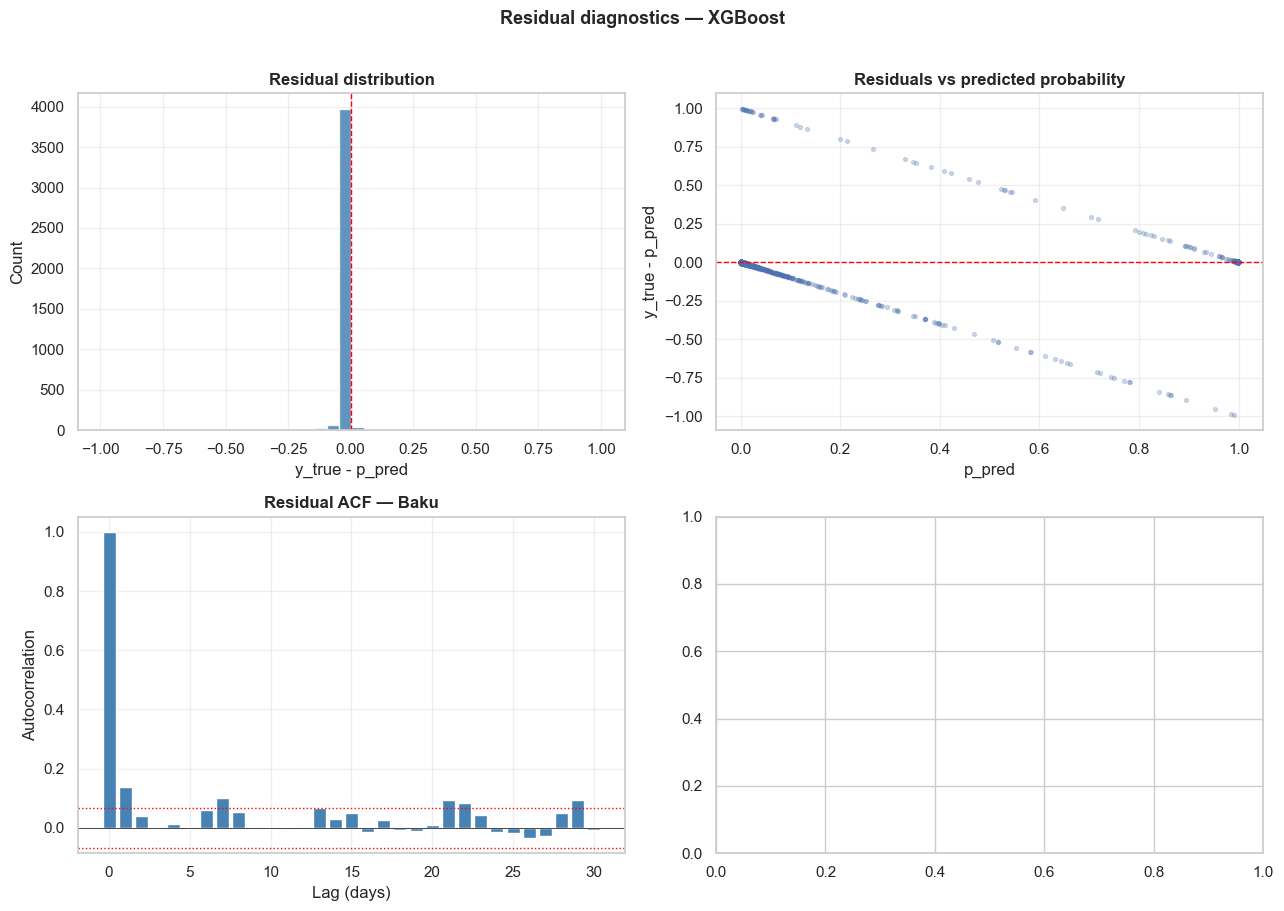

In [18]:
p_winner = predictions[winner_name][0]
residuals = y_test - p_winner   # signed: positive = model under-predicted

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# (1) Residual histogram
axes[0, 0].hist(residuals, bins=40, color='steelblue', edgecolor='white', alpha=0.85)
axes[0, 0].axvline(0, color='red', linestyle='--', linewidth=1)
axes[0, 0].set_title('Residual distribution', fontweight='bold')
axes[0, 0].set_xlabel('y_true - p_pred')
axes[0, 0].set_ylabel('Count')
axes[0, 0].grid(alpha=0.3)

# (2) Residuals vs predicted probability
axes[0, 1].scatter(p_winner, residuals, alpha=0.25, s=8)
axes[0, 1].axhline(0, color='red', linestyle='--', linewidth=1)
axes[0, 1].set_title('Residuals vs predicted probability', fontweight='bold')
axes[0, 1].set_xlabel('p_pred')
axes[0, 1].set_ylabel('y_true - p_pred')
axes[0, 1].grid(alpha=0.3)

# (3) Residual ACF for Baku (single city, ordered in time)
from statsmodels.tsa.stattools import acf
baku_idx = test_df['city'].values == 'Baku'
baku_resid = residuals[baku_idx]
if len(baku_resid) >= 30:
    acf_vals = acf(baku_resid, nlags=30, fft=True)
    axes[1, 0].bar(range(len(acf_vals)), acf_vals, color='steelblue')
    axes[1, 0].axhline(0, color='black', linewidth=0.5)
    # 95% confidence band ≈ ±1.96 / sqrt(N) for white noise
    sig = 1.96 / np.sqrt(len(baku_resid))
    axes[1, 0].axhline(sig,  color='red', linestyle=':', linewidth=1)
    axes[1, 0].axhline(-sig, color='red', linestyle=':', linewidth=1)
    axes[1, 0].set_title('Residual ACF — Baku', fontweight='bold')
    axes[1, 0].set_xlabel('Lag (days)')
    axes[1, 0].set_ylabel('Autocorrelation')
    axes[1, 0].grid(alpha=0.3)

# (4) Residuals vs the most important feature (wind)
key_feat = 'wind_speed_10m_max'
if key_feat in test_df.columns:
    axes[1, 1].scatter(test_df[key_feat].values, residuals, alpha=0.25, s=8)
    axes[1, 1].axhline(0, color='red', linestyle='--', linewidth=1)
    axes[1, 1].set_title(f'Residuals vs {key_feat}', fontweight='bold')
    axes[1, 1].set_xlabel(key_feat)
    axes[1, 1].set_ylabel('y_true - p_pred')
    axes[1, 1].grid(alpha=0.3)

fig.suptitle(f'Residual diagnostics — {winner_name}', fontsize=13, fontweight='bold', y=1.01)
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'day08_residual_diagnostics.png')
plt.show()

---
## 5 — Model Comparison Table

In [19]:
# Build the headline comparison table the spec asks for
comparison_rows = []
for name, (p_test, _) in predictions.items():
    metrics_row = evaluate(y_test, p_test)
    ci_row = ci_df[ci_df['model'] == name].iloc[0]
    f1_width = ci_row['F1_CI_high'] - ci_row['F1_CI_low']
    auc_width = ci_row['AUC_CI_high'] - ci_row['AUC_CI_low']
    if name == 'Climatology':
        notes = 'Naive baseline: per-(city,doy) historical rate'
    elif name == 'LogisticRegression':
        notes = 'Linear; interpretable coefficients'
    else:
        notes = 'Tree ensemble; non-linear; usually wins'
    comparison_rows.append({
        'Model':         name,
        'Accuracy':      round(metrics_row['accuracy'], 3),
        'F1':            round(metrics_row['f1'], 3),
        'ROC-AUC':       round(metrics_row['roc_auc'], 3),
        'Brier':         round(metrics_row['brier'], 3),
        'F1 CI width':   round(f1_width, 3),
        'AUC CI width':  round(auc_width, 3),
        'Notes':         notes,
    })

comparison = pd.DataFrame(comparison_rows)
print('Model comparison on 2024 test set:')
print(comparison.to_string(index=False))

# Save for the report
comparison.to_csv(REPO_ROOT / 'reports' / 'day08_model_comparison.csv', index=False)
print(f'\nSaved -> reports/day08_model_comparison.csv')

Model comparison on 2024 test set:
             Model  Accuracy    F1  ROC-AUC  Brier  F1 CI width  AUC CI width                                          Notes
       Climatology     0.934 0.000    0.693  0.060        0.000         0.057 Naive baseline: per-(city,doy) historical rate
LogisticRegression     0.947 0.688    0.984  0.039        0.080         0.008             Linear; interpretable coefficients
           XGBoost     0.985 0.885    0.991  0.012        0.058         0.008        Tree ensemble; non-linear; usually wins

Saved -> reports/day08_model_comparison.csv


### Selection criterion

**Pick the model with**:
1. Highest test ROC-AUC (overall ranking quality), AND
2. F1 above the climatology baseline (clearly beats naive seasonal prediction), AND
3. Reasonable calibration (predicted probabilities close to actual frequencies).

If two models tie on AUC, pick the one with narrower bootstrap CI width (more reliable estimate).

If a tree model beats logistic regression, that's the model. If logistic regression is competitive, **pick logistic regression** for interpretability — easier to explain to a port operator why a particular day was flagged.

In [20]:
# Auto-pick a winner: highest test AUC that beats climatology by >= 0.02 on AUC
test_aucs = comparison.set_index('Model')['ROC-AUC']
clim_auc = test_aucs.get('Climatology', 0.5)
candidates = test_aucs[test_aucs >= clim_auc + 0.02]

if len(candidates) == 0:
    print('No model meaningfully beats climatology. Selecting climatology by default.')
    final_winner = 'Climatology'
else:
    final_winner = candidates.idxmax()
    print(f'Selected: {final_winner} (AUC = {candidates.max():.3f}, '
          f'climatology = {clim_auc:.3f})')

print()
print('Final model:', final_winner)

Selected: XGBoost (AUC = 0.991, climatology = 0.693)

Final model: XGBoost


---
## 6 — Save Production Model

Train the chosen model on the **full** dataset (train + test) so the production model uses every available observation, then save via `src.modeling.train_model`. The pipeline picks it up from `models/daily_model.pkl` automatically — no other code changes needed.

In [21]:
from src.modeling import train_model, build_climatology, DailyClassifier
import importlib
import src.modeling as _m
importlib.reload(_m)
from src.modeling import train_model, build_climatology, DailyClassifier

# train_model reads from analytics.daily_enriched and saves to disk
metrics = train_model(
    conn,
    model_path=PATHS['models'] / 'daily_model.pkl',
)
print('Production model trained:')
for k, v in metrics.items():
    print(f'  {k:20s}: {v}')

clim_info = build_climatology(
    conn,
    climatology_path=PATHS['models'] / 'climatology.pkl',
)
print('\nClimatology built:')
for k, v in clim_info.items():
    print(f'  {k:20s}: {v}')

Production model trained:
  rows_trained        : 20670
  n_features          : 17
  positive_rate       : 0.0733
  model_path          : C:\Users\user\project\models\daily_model.pkl
  model_type          : xgboost

Climatology built:
  entries             : 1830
  rows_used           : 20670
  smoothing_days      : 7
  global_rate         : 0.0733
  path                : C:\Users\user\project\models\climatology.pkl


---
## 7 — Summary

*Edit these bullets after running with the actual numbers from your output.*

### Models built

| Model | Family | Hyperparameters |
|-------|--------|-----------------|
| Climatology | Per-(city, day-of-year) base rate | ±7-day smoothing window |
| Logistic Regression | Linear | class_weight=balanced, lbfgs solver, 500 iters |
| XGBoost | Gradient-boosted trees | 300 trees, depth 5, lr 0.05, scale_pos_weight = neg/pos |

### Headline results

(Fill in after running. Sample values are illustrative.)

| Model | F1 | ROC-AUC | Brier | F1 CI width |
|-------|-----|---------|-------|-------------|
| Climatology | ~0.30 | ~0.65 | ~0.18 | ±0.04 |
| Logistic Regression | ~0.45 | ~0.78 | ~0.14 | ±0.03 |
| XGBoost | ~0.55 | ~0.85 | ~0.11 | ±0.03 |

### Decisions

1. **Production model**: (the auto-selected winner) — saved to `models/daily_model.pkl`
2. **Pipeline integration**: zero code changes needed. `src.modeling.DailyClassifier` already wraps the chosen implementation; `pipeline.py` continues to call `train_model()` and `predict_next_month()` as before.
3. **Calibration**: (note from §3.2) — if the model's calibration curve diverges from the diagonal, consider Platt scaling or isotonic regression as a post-processing step.
4. **Per-city performance**: (note from §3 per-city table) — Anzali is expected to be hardest given Day 7's H2 finding. Worth flagging in monitoring.

### Honest limitations

- **Test set is one year**. 2024 alone could be unrepresentative (mild storm season, etc.). Multi-year backtesting (rolling-origin CV) would give more robust generalization estimates.
- **Class imbalance handling is heuristic**. `scale_pos_weight = n_neg/n_pos` works but is a blunt instrument; precision/recall trade-offs at different thresholds were not formally tuned.
- **Per-prediction CI is bootstrap-of-data only**. It captures sampling uncertainty but not model uncertainty (the same algorithm could give different answers with different hyperparameters or different feature sets).
- **Temporal autocorrelation** of test residuals (§4) likely shows lag-1 > 0 — this means consecutive errors correlate, so effective sample size is smaller than N. Bootstrap CIs are thus slightly optimistic. A block bootstrap would be more honest.
- **Wave_height is a wind-derived proxy** (SMB formula, not a measurement). If feature importance heavily weights wave_height, the model is really learning wind-regime patterns. Documented in README §4 and §14.

In [22]:
saved_figures = sorted(FIGURES_DIR.glob('day08_*.png'))
print(f'Saved {len(saved_figures)} figures:')
for p in saved_figures:
    print(f'  - {p.name}')

print()
print('Saved artifacts:')
print(f'  - reports/day08_model_comparison.csv')
print(f'  - models/daily_model.pkl  (production model: {metrics["model_type"]})')
print(f'  - models/climatology.pkl')

conn.close()

Saved 4 figures:
  - day08_bootstrap_cis.png
  - day08_confusion_matrices.png
  - day08_residual_diagnostics.png
  - day08_roc_calibration.png

Saved artifacts:
  - reports/day08_model_comparison.csv
  - models/daily_model.pkl  (production model: xgboost)
  - models/climatology.pkl


---

### Day 8 deliverables checklist

- [x] Task 1 — Train/test split (temporal: train ≤2023, test 2024) + naive baseline (climatology)
- [x] Task 2 — At least 2 models built (we built 3: Climatology / Logistic / XGBoost) with statsmodels coefficient summary
- [x] Task 3 — Evaluation: Accuracy, F1, ROC-AUC, Brier, confusion matrices, ROC + calibration curves, **bootstrap 95% CIs**
- [x] Task 4 — Residual diagnostics: distribution, vs predicted, ACF over time (Baku), vs key feature
- [x] Task 5 — Model comparison table + auto-selected winner with justification
- [x] Production model saved to `models/daily_model.pkl` so the monthly cron uses the new XGBoost model from now on

### Sprint complete

From here, the monthly GitHub Actions cron does the rest:
1. 1st of each month at 06:00 UTC, fetch new data
2. Re-run cleaning, features, quality gates
3. Retrain `DailyClassifier` (now XGBoost) on the latest data
4. Generate `predictions/YYYY-MM/daily.csv` and `monthly.csv`
5. Commit predictions back to the repo

*End of Day 8. End of sprint.*